In [294]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

## 1. Análisis y preprocesamiento

In [295]:
X = np.load('data/X_images.npy')
y = np.load('data/y_images.npy')
X.shape, y.shape

((5000, 784), (5000,))

In [296]:
min(y), max(y)

(0, 48)

Chequeo desbalanceo

<Axes: xlabel='y'>

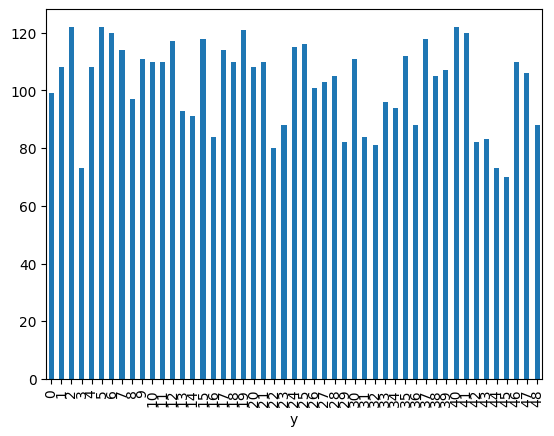

In [321]:
y_df = pd.DataFrame(y, columns=['y'])
y_df['y'].value_counts().sort_index().plot(kind='bar')

Imagen 665:
Etiqueta: 9


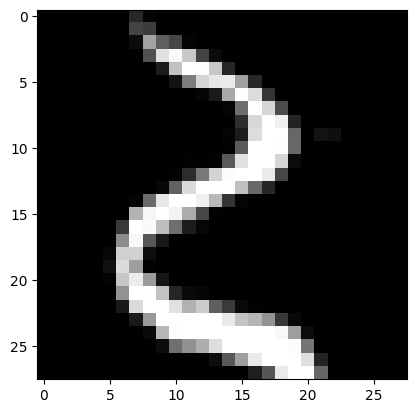

Imagen 1184:
Etiqueta: 16


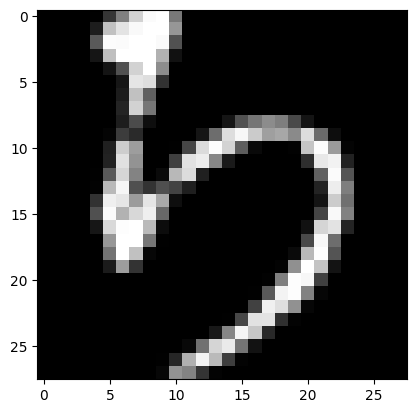

Imagen 3217:
Etiqueta: 45


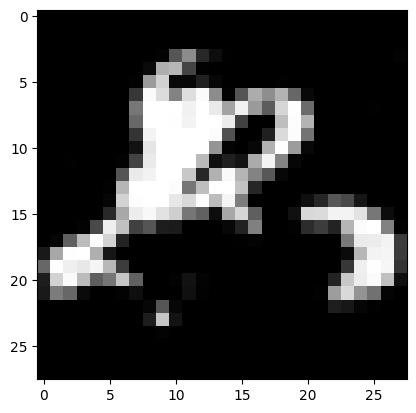

In [297]:
# Visualización de les imagenes
def ver_k_imagenes(X, y, cantidad):

    nro_imagenes = X.shape[0]
    nro_imagenes_mostrar = cantidad

    img_mostrar = np.random.randint(0, nro_imagenes, nro_imagenes_mostrar)
    for i in img_mostrar:
        print(f"Imagen {i}:")
        print(f"Etiqueta: {y[i]}")
        plt.imshow(X[i].reshape(28, 28), cmap='gray')
        plt.show()

ver_k_imagenes(X, y, 3)

In [298]:
data_df = pd.concat([pd.DataFrame(X.reshape(X.shape[0], -1)), pd.DataFrame(y)], axis=1)

In [299]:
from src import data_splitting

dev_df, test_df = data_splitting.train_val_split(data_df)
dev_df.shape, test_df.shape

((4000, 785), (1000, 785))

In [300]:
train_df, val_df = data_splitting.train_val_split(dev_df)
train_df.shape, val_df.shape

((3200, 785), (800, 785))

Imagen 2354:
Etiqueta: [8]


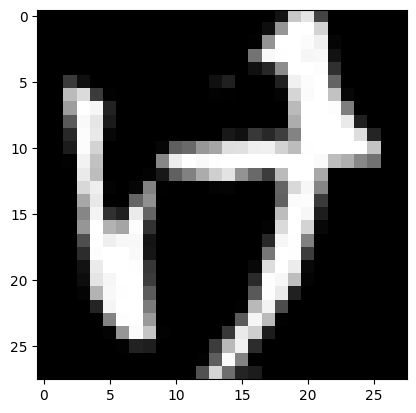

Imagen 120:
Etiqueta: [45]


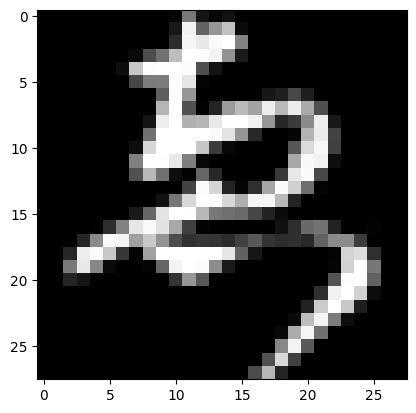

Imagen 210:
Etiqueta: [47]


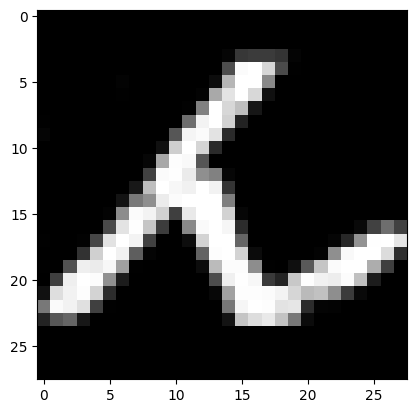

In [301]:
X_train_df = pd.DataFrame(train_df.iloc[:, :-1].values)
y_train_df = pd.DataFrame(train_df.iloc[:, -1].values, columns=['y'])
X_val_df = pd.DataFrame(val_df.iloc[:, :-1].values)
y_val_df = pd.DataFrame(val_df.iloc[:, -1].values, columns=['y'])
X_test_df = pd.DataFrame(test_df.iloc[:, :-1].values)
y_test_df = pd.DataFrame(test_df.iloc[:, -1].values, columns=['y'])

# Paso a numpy
X_train = X_train_df.values.reshape(X_train_df.shape[0], 784, 1)
y_train = y_train_df.values
X_val = X_val_df.values.reshape(X_val_df.shape[0], 784, 1)
y_val = y_val_df.values
X_test = X_test_df.values.reshape(X_test_df.shape[0], 784, 1)
y_test = y_test_df.values
ver_k_imagenes(X_train, y_train, 3)


In [302]:
#Normalización
X_train = X_train / 255
# y_train = y_train / 255
X_val = X_val / 255
# y_val = y_val / 255
X_test = X_test / 255
# y_test = y_test / 255

X_train.mean(), y_train.mean()

(0.18405846, 23.2853125)

In [303]:
# Pasp y a ohe
from src import models, preprocessing
importlib.reload(preprocessing)
from src.preprocessing import ohe

y_values = list(range(49))

y_train_ohe_df = ohe(y_train_df, 'y', y_values)
y_val_ohe_df = ohe(y_val_df, 'y', y_values)
y_test_ohe_df = ohe(y_test_df, 'y', y_values)

# Paso a numpy
y_train_ohe = y_train_ohe_df.values
y_val_ohe = y_val_ohe_df.values
y_test_ohe = y_test_ohe_df.values
y_train_ohe_df.head(3)

,y_0,y_1,y_2,y_3,y_4,y_5,y_6,y_7,y_8,y_9,...,y_39,y_40,y_41,y_42,y_43,y_44,y_45,y_46,y_47,y_48
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


## 2. Implementación y Entrenamiento de una Red Neuronal Básica

Implementación --> models.py

In [ ]:
from src import models
importlib.reload(models)

from src.models import NN


# Entrenamiento
# Datos
input_shape = X_train.shape[1]
output_shape = y_train_ohe.shape[1]
neurons_per_hidden_layer = [100, 80]
# hiperparams
lr = 0.1
n_epochs = 400
M0 = NN(input_shape, output_shape, neurons_per_hidden_layer, lr)

M0_history = M0.fit(X_train, y_train_ohe, X_val, y_val_ohe, n_epochs)


Epoch 1/400, Train loss: 4.054506373462438
Epoch 2/400, Train loss: 3.993237951535022
Epoch 3/400, Train loss: 3.9513930559244845
Epoch 4/400, Train loss: 3.918703401302181
Epoch 5/400, Train loss: 3.891489412768811
Epoch 6/400, Train loss: 3.8678981572654845
Epoch 7/400, Train loss: 3.846510195459186
Epoch 8/400, Train loss: 3.826875710297503
Epoch 9/400, Train loss: 3.8082980783002607
Epoch 10/400, Train loss: 3.7906026132661506
Epoch 11/400, Train loss: 3.7735150028777316
Epoch 12/400, Train loss: 3.756885560135603
Epoch 13/400, Train loss: 3.740486723190054
Epoch 14/400, Train loss: 3.7240657170435423
Epoch 15/400, Train loss: 3.7075897590706215
Epoch 16/400, Train loss: 3.6910997571860777
Epoch 17/400, Train loss: 3.6746447712198056
Epoch 18/400, Train loss: 3.658063623647597
Epoch 19/400, Train loss: 3.6412868448052143
Epoch 20/400, Train loss: 3.624454203549092
Epoch 21/400, Train loss: 3.607444082150102
Epoch 22/400, Train loss: 3.590144675057312
Epoch 23/400, Train loss: 3.572

In [329]:
M0_train_loss_final = M0_history['train_loss'][-1]
M0_val_loss_final = M0_history['val_loss'][-1]
M0_train_time = 4.29

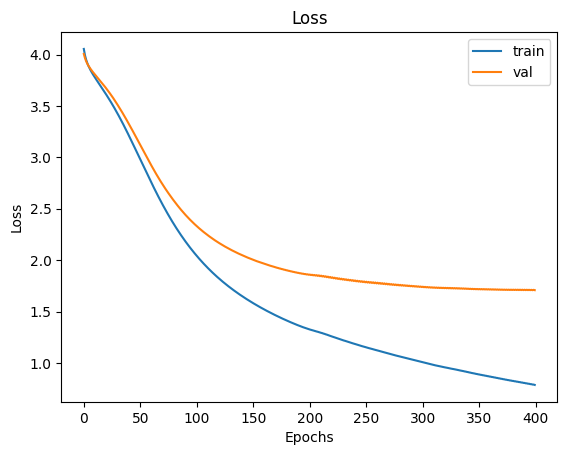

In [319]:
# Visualización de losses

plt.plot(M0_history['train_loss'], label='train')
plt.plot(M0_history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

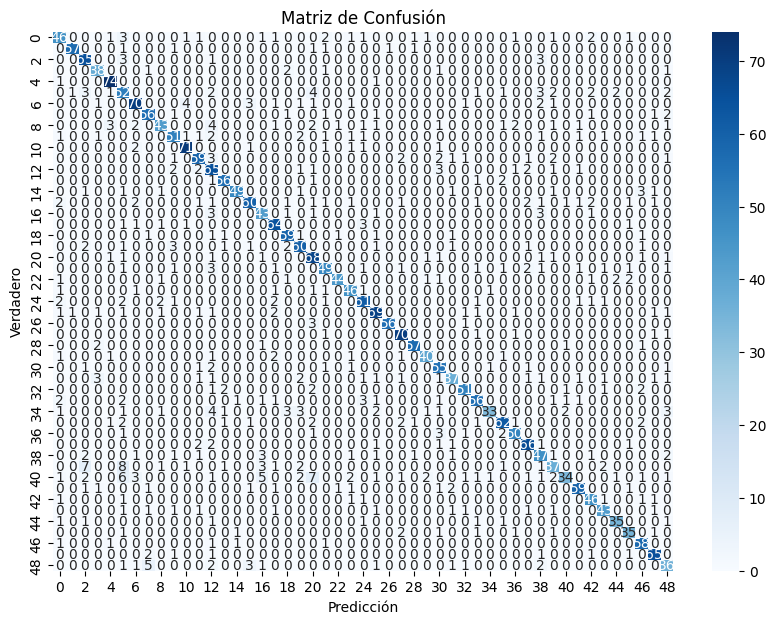

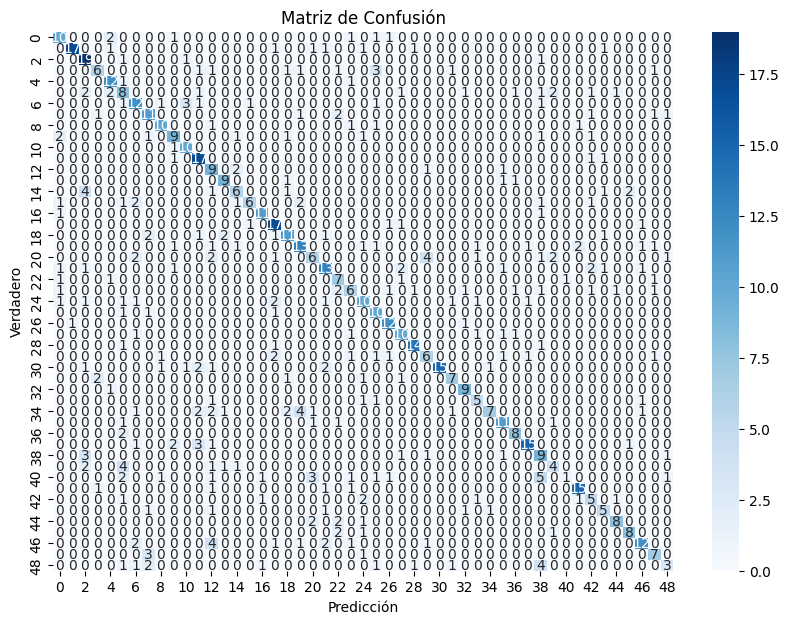

Accuracy train: 0.81
Accuracy val  : 0.59


In [ ]:
# Métricas

from src import metrics, models
importlib.reload(models)
importlib.reload(metrics)
from src.models import NN
from src.metrics import get_confusion_matrix, accuracy

# pasar de one-hot a entero
y_train_labels = np.argmax(y_train_ohe, axis=1)   # (N,)
y_val_labels   = np.argmax(y_val_ohe,   axis=1)

y_train_pred = M0.predict(X_train)  # (N,)
y_val_pred   = M0.predict(X_val)

cm_train = get_confusion_matrix(y_train_labels, y_train_pred, plot=True)
cm_val   = get_confusion_matrix(y_val_labels,   y_val_pred,   plot=True)

acc_train_M0 = accuracy(y_train_labels, y_train_pred)
acc_val_M0   = accuracy(y_val_labels,   y_val_pred)
print(f"Accuracy train: {acc_train_M0:.2f}")
print(f"Accuracy val  : {acc_val_M0:.2f}")

## 3. Implementación y Entrenamiento de una Red Neuronal Avanzada

Vamos implementando de a un cambio a la vez para ver su efecto.

– 3.1 Rate scheduling lineal (con saturación) y exponencial.

– 3.2 Mini-batch stochastic gradient descent.

– 3.3 Optimizador ADAM.

– 3.4 Regularización L2.

– 3.5 Regularización mediante early stopping.

– 3.6 OPCIONAL: Regularización mediante dropout.

– 3.7 OPCIONAL: batch normalization.

3.1 Rate scheduling

Caso lineal:

Epoch 1/400, Train loss: 4.054506373462438
Epoch 2/400, Train loss: 3.993237951535022
Epoch 3/400, Train loss: 3.9514852383112573
Epoch 4/400, Train loss: 3.9189095392107123
Epoch 5/400, Train loss: 3.891858195087212
Epoch 6/400, Train loss: 3.8684574035529793
Epoch 7/400, Train loss: 3.8472541860439184
Epoch 8/400, Train loss: 3.827856627265207
Epoch 9/400, Train loss: 3.809554605393221
Epoch 10/400, Train loss: 3.792120951704856
Epoch 11/400, Train loss: 3.7753466901584174
Epoch 12/400, Train loss: 3.7590510355948528
Epoch 13/400, Train loss: 3.7430599799119655
Epoch 14/400, Train loss: 3.7270883098855863
Epoch 15/400, Train loss: 3.711117637677825
Epoch 16/400, Train loss: 3.6951340999154856
Epoch 17/400, Train loss: 3.6792842847449405
Epoch 18/400, Train loss: 3.6633466783945043
Epoch 19/400, Train loss: 3.647290811203378
Epoch 20/400, Train loss: 3.631182554413446
Epoch 21/400, Train loss: 3.6150417810293964
Epoch 22/400, Train loss: 3.5986845089813317
Epoch 23/400, Train loss: 3.

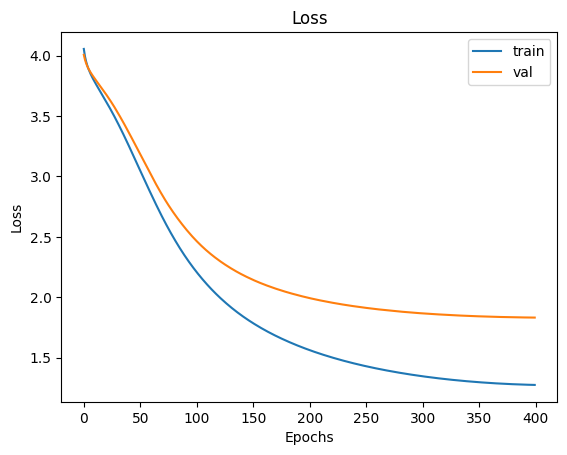

Accuracy train: 0.68
Accuracy val  : 0.54


In [ ]:
from src import models
importlib.reload(models)
from src.models import NN

# hiperparams
lr0 = 0.1
lr_final = 0.005
n_epochs = 400

# Modelo y entrenamiento
M1a = NN(input_shape, output_shape, neurons_per_hidden_layer, lr0)
M1a_history = M1a.fit(X_train, y_train_ohe, X_val, y_val_ohe, n_epochs, schedule_type='linear', lr_final=lr_final)

# Visualización de losses
plt.plot(M1a_history['train_loss'], label='train')
plt.plot(M1a_history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


#Accuracy
y_train_pred = M1a.predict(X_train)  # (N,)
y_val_pred = M1a.predict(X_val)

acc_train_M1a = accuracy(y_train_labels, y_train_pred)
acc_val_M1a   = accuracy(y_val_labels, y_val_pred)
print(f"Accuracy train: {acc_train_M1a:.2f}")
print(f"Accuracy val: {acc_val_M1a:.2f}")


In [363]:
final_train_loss_M1a = M1a_history['train_loss'][-1]
final_val_loss_M1a = M1a_history['val_loss'][-1]
final_train_time_M1a = 4.29
print(f"Final train loss: {final_train_loss_M1a:.4f}")
print(f"Final val loss: {final_val_loss_M1a:.4f}")

Final train loss: 1.2749
Final val loss: 1.8319


In [ ]:
M1a_train_time = 4.22

Caso exponencial:

Epoch 1/400, Train loss: 4.054506373462438
Epoch 2/400, Train loss: 3.993237951535022
Epoch 3/400, Train loss: 3.9517794592435065
Epoch 4/400, Train loss: 3.919634608396624
Epoch 5/400, Train loss: 3.893035554145749
Epoch 6/400, Train loss: 3.8701937361484586
Epoch 7/400, Train loss: 3.849543508849235
Epoch 8/400, Train loss: 3.83081799189217
Epoch 9/400, Train loss: 3.813321029798433
Epoch 10/400, Train loss: 3.796746354459915
Epoch 11/400, Train loss: 3.780900408865612
Epoch 12/400, Train loss: 3.7656546888706766
Epoch 13/400, Train loss: 3.7508242271547925
Epoch 14/400, Train loss: 3.7362411874130026
Epoch 15/400, Train loss: 3.7218014384239178
Epoch 16/400, Train loss: 3.7074421949006116
Epoch 17/400, Train loss: 3.6932196104788715
Epoch 18/400, Train loss: 3.679174732404186
Epoch 19/400, Train loss: 3.665206024589638
Epoch 20/400, Train loss: 3.6512249592084896
Epoch 21/400, Train loss: 3.637288371813897
Epoch 22/400, Train loss: 3.6234815313563775
Epoch 23/400, Train loss: 3.6096

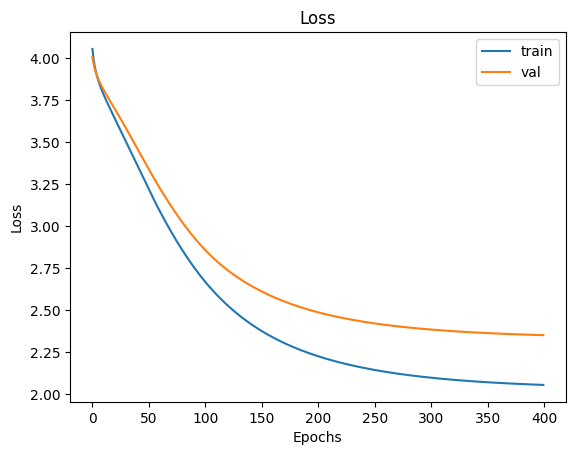

Accuracy train: 0.53
Accuracy val  : 0.42


In [328]:
from src import models
importlib.reload(models)
from src.models import NN

# hiperparams
lr0 = 0.1
decay_lambda = 0.01
n_epochs = 400

# Modelo y entrenamiento
M1b = NN(input_shape, output_shape, neurons_per_hidden_layer, lr0)
M1b_history = M1b.fit(X_train, y_train_ohe, X_val, y_val_ohe, n_epochs, schedule_type='exponential', decay_lambda=decay_lambda)

# Visualización de losses
plt.plot(M1b_history['train_loss'], label='train')
plt.plot(M1b_history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

M1b_train_loss_final = M1b_history['train_loss'][-1]
M1b_val_loss_final = M1b_history['val_loss'][-1]

#Accuracy
y_train_pred = M1b.predict(X_train)  # (N,)
y_val_pred   = M1b.predict(X_val)

acc_train_M1b = accuracy(y_train_labels, y_train_pred)
acc_val_M1b   = accuracy(y_val_labels,   y_val_pred)
print(f"Accuracy train: {acc_train_M1b:.2f}")
print(f"Accuracy val  : {acc_val_M1b:.2f}")


In [ ]:
M1b_train_time = 4.9

3.2 Mini-batch stochastic gradient descent.

Epoch 1/400, Train loss: 3.6840359209539155
Epoch 2/400, Train loss: 2.877927509138574
Epoch 3/400, Train loss: 2.2986684599634164
Epoch 4/400, Train loss: 1.9699146045885374
Epoch 5/400, Train loss: 1.7796809793294173
Epoch 6/400, Train loss: 1.6471589450597315
Epoch 7/400, Train loss: 1.5550426136517372
Epoch 8/400, Train loss: 1.4640486728311808
Epoch 9/400, Train loss: 1.4121678983250874
Epoch 10/400, Train loss: 1.356013512964908
Epoch 11/400, Train loss: 1.3128862364532956
Epoch 12/400, Train loss: 1.2687029059130102
Epoch 13/400, Train loss: 1.2272225141472228
Epoch 14/400, Train loss: 1.2072763609729749
Epoch 15/400, Train loss: 1.172606112787882
Epoch 16/400, Train loss: 1.1504136122384196
Epoch 17/400, Train loss: 1.1171129824266444
Epoch 18/400, Train loss: 1.0850910391678732
Epoch 19/400, Train loss: 1.0730700018126944
Epoch 20/400, Train loss: 1.0514304286324643
Epoch 21/400, Train loss: 1.0274280494234866
Epoch 22/400, Train loss: 1.0201598246005903
Epoch 23/400, Train lo

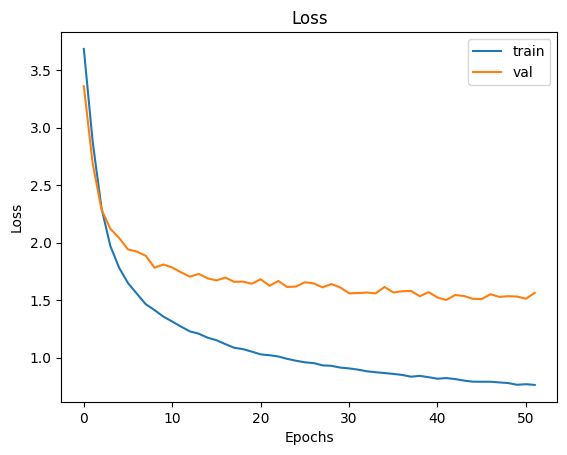

Accuracy train: 0.24
Accuracy val: 0.18


In [347]:
from src import models
importlib.reload(models)
from src.models import NN

# hiperparams
lr = 0.1
n_epochs = 400
batch_size = 64

# Modelo y entrenamiento
M1c = NN(input_shape, output_shape, neurons_per_hidden_layer, lr, batch_size=batch_size)
M1c_history = M1c.fit(X_train, y_train_ohe, X_val, y_val_ohe, n_epochs)

# Visualización de losses
plt.plot(M1c_history['train_loss'], label='train')
plt.plot(M1c_history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


#Accuracy
y_train_pred = M1c.predict(X_train)  # (N,)
y_val_pred = M1c.predict(X_val)

acc_train_M1c = accuracy(y_train_labels, y_train_pred)
acc_val_M1c   = accuracy(y_val_labels, y_val_pred)
print(f"Accuracy train: {acc_train_M1c:.2f}")
print(f"Accuracy val: {acc_val_M1c:.2f}")


In [333]:
epoch_optima_M1c = np.argmin(M1c_history['val_loss'])
epoch_optima_M1c

9

SGD por 9 epochs:

Epoch 1/19, Train loss: 3.79108712639359
Epoch 2/19, Train loss: 3.353719241502686
Epoch 3/19, Train loss: 2.858470683775483
Epoch 4/19, Train loss: 2.4214938982324012
Epoch 5/19, Train loss: 2.0990165056254217
Epoch 6/19, Train loss: 1.8742532225099833
Epoch 7/19, Train loss: 1.6927802268383119
Epoch 8/19, Train loss: 1.5578279102497448
Epoch 9/19, Train loss: 1.4462464778062634
Epoch 10/19, Train loss: 1.3592183483922817
Epoch 11/19, Train loss: 1.2652855707893185
Epoch 12/19, Train loss: 1.1937670572839463
Epoch 13/19, Train loss: 1.1205143030268405
Epoch 14/19, Train loss: 1.0594768036810378
Epoch 15/19, Train loss: 0.9979754457853222
Epoch 16/19, Train loss: 0.9469471624614916
Epoch 17/19, Train loss: 0.8909307098834881
Epoch 18/19, Train loss: 0.8400367913801843
Epoch 19/19, Train loss: 0.7943410761792501


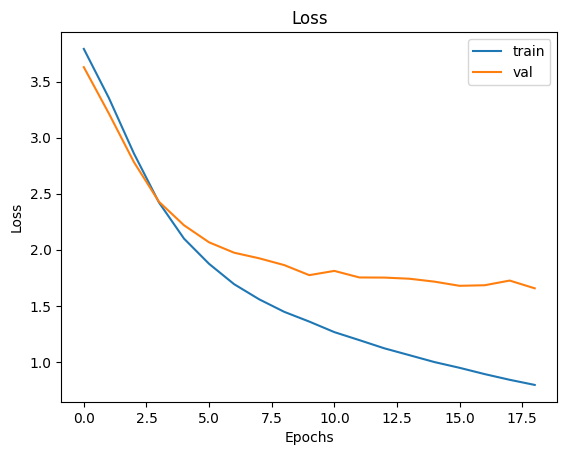

Accuracy train: 0.82
Accuracy val: 0.60


In [339]:
from src import models
importlib.reload(models)
from src.models import NN

# hiperparams
lr = 0.05
n_epochs = 19
batch_size = 64

# Modelo y entrenamiento
M1c = NN(input_shape, output_shape, neurons_per_hidden_layer, lr, batch_size=batch_size)
M1c_history = M1c.fit(X_train, y_train_ohe, X_val, y_val_ohe, n_epochs)

# Visualización de losses
plt.plot(M1c_history['train_loss'], label='train')
plt.plot(M1c_history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


#Accuracy
y_train_pred = M1c.predict(X_train)  # (N,)
y_val_pred = M1c.predict(X_val)

acc_train_M1c = accuracy(y_train_labels, y_train_pred)
acc_val_M1c   = accuracy(y_val_labels, y_val_pred)
print(f"Accuracy train: {acc_train_M1c:.2f}")
print(f"Accuracy val: {acc_val_M1c:.2f}")


3.3 Optimizador ADAM.

Epoch 1/29, Train loss: 4.054506373462423
Epoch 2/29, Train loss: 7.141113318339246
Epoch 3/29, Train loss: 6.107649307744265
Epoch 4/29, Train loss: 5.379267398012968
Epoch 5/29, Train loss: 3.8746554875305805
Epoch 6/29, Train loss: 3.5788513489696534
Epoch 7/29, Train loss: 3.4974983354367133
Epoch 8/29, Train loss: 3.4342661593776547
Epoch 9/29, Train loss: 3.302190602128509
Epoch 10/29, Train loss: 3.222752908503807
Epoch 11/29, Train loss: 3.103379603968587
Epoch 12/29, Train loss: 3.0397964877514467
Epoch 13/29, Train loss: 2.8736329953092734
Epoch 14/29, Train loss: 2.8640537441154237
Epoch 15/29, Train loss: 2.933251423270874
Epoch 16/29, Train loss: 2.609939428401524
Epoch 17/29, Train loss: 2.6582908656748754
Epoch 18/29, Train loss: 2.5200454375989936
Epoch 19/29, Train loss: 2.4441436407540684
Epoch 20/29, Train loss: 2.3288035676979133
Epoch 21/29, Train loss: 2.235373729886478
Epoch 22/29, Train loss: 2.1558439388242716
Epoch 23/29, Train loss: 2.036134768254739
Epoch 24

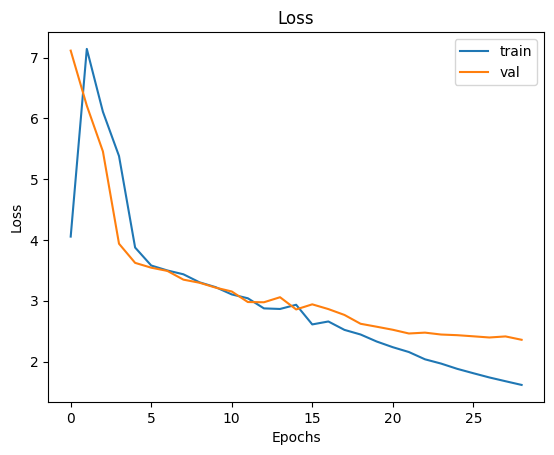

Accuracy train: 0.56
Accuracy val: 0.43


In [343]:
from src import models
importlib.reload(models)
from src.models import NN

# hiperparams
lr = 0.05
n_epochs = 29
batch_size = len(X_train)
optimizer = 'adam'
beta_1 = 0.9
beta_2 = 0.999
epsilon = 1e-8

# Modelo y entrenamiento
M1d = NN(input_shape,
         output_shape,
         neurons_per_hidden_layer,
         lr,
         optimizer=optimizer,
         beta_1=beta_1,
         beta_2=beta_2,
         epsilon=epsilon,
         batch_size=batch_size)

M1d_history = M1d.fit(X_train,
                      y_train_ohe,
                      X_val,
                      y_val_ohe,
                      n_epochs)

# Visualización de losses
plt.plot(M1d_history['train_loss'], label='train')
plt.plot(M1d_history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


#Accuracy
y_train_pred = M1d.predict(X_train)  # (N,)
y_val_pred = M1d.predict(X_val)

acc_train_M1d = accuracy(y_train_labels, y_train_pred)
acc_val_M1d   = accuracy(y_val_labels, y_val_pred)
print(f"Accuracy train: {acc_train_M1d:.2f}")
print(f"Accuracy val: {acc_val_M1d:.2f}")


In [341]:
epoch_optima_M1d = np.argmin(M1d_history['val_loss'])
epoch_optima_M1d

28

3.4 Regularización L2.

Epoch 1/400, Train loss: 6.326746397640593
Epoch 2/400, Train loss: 17.391808748430563
Epoch 3/400, Train loss: 20.097337661952658
Epoch 4/400, Train loss: 10.97040013020965
Epoch 5/400, Train loss: 9.156969547536791
Epoch 6/400, Train loss: 8.900030437953463
Epoch 7/400, Train loss: 9.025916394165025
Epoch 8/400, Train loss: 10.062139723447705
Epoch 9/400, Train loss: 12.060111151014775
Epoch 10/400, Train loss: 11.537179600004317
Epoch 11/400, Train loss: 11.45949297311536
Epoch 12/400, Train loss: 14.76535511571368
Epoch 13/400, Train loss: 15.851083000493166
Epoch 14/400, Train loss: 15.389024898885475
Epoch 15/400, Train loss: 12.964706052115153
Epoch 16/400, Train loss: 13.309908607291886
Epoch 17/400, Train loss: 13.583934057045553
Epoch 18/400, Train loss: 13.64567884150925
Epoch 19/400, Train loss: 13.910194570467791
Epoch 20/400, Train loss: 13.629590435132231
Epoch 21/400, Train loss: 13.36585039080958
Epoch 22/400, Train loss: 12.903926166615936
Epoch 23/400, Train loss: 12

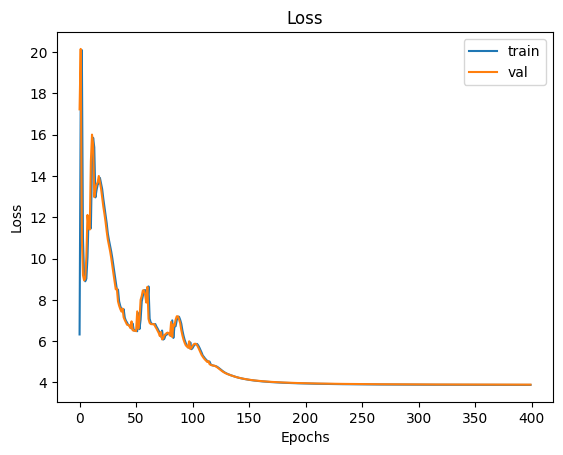

Accuracy train: 0.03
Accuracy val: 0.03


In [344]:
from src import models
importlib.reload(models)
from src.models import NN

# hiperparams
lr = 0.1
n_epochs = 400
batch_size = len(X_train)
l2_lambda = 0.01

# Modelo y entrenamiento
M1d = NN(input_shape,
         output_shape,
         neurons_per_hidden_layer,
         lr,
         optimizer=optimizer,
         batch_size=batch_size,
         l2=l2_lambda)

M1d_history = M1d.fit(X_train,
                      y_train_ohe,
                      X_val,
                      y_val_ohe,
                      n_epochs)

# Visualización de losses
plt.plot(M1d_history['train_loss'], label='train')
plt.plot(M1d_history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


#Accuracy
y_train_pred = M1d.predict(X_train)  # (N,)
y_val_pred = M1d.predict(X_val)

acc_train_M1d = accuracy(y_train_labels, y_train_pred)
acc_val_M1d   = accuracy(y_val_labels, y_val_pred)
print(f"Accuracy train: {acc_train_M1d:.2f}")
print(f"Accuracy val: {acc_val_M1d:.2f}")


3.5 Regularización mediante early stopping.

Epoch 1/400, Train loss: 4.07322980121836
Epoch 2/400, Train loss: 3.9922971817886097
Epoch 3/400, Train loss: 3.949266890577892
Epoch 4/400, Train loss: 3.918239044459188
Epoch 5/400, Train loss: 3.893486069006225
Epoch 6/400, Train loss: 3.8727023846651547
Epoch 7/400, Train loss: 3.854475031644821
Epoch 8/400, Train loss: 3.837633177221045
Epoch 9/400, Train loss: 3.8217508025047158
Epoch 10/400, Train loss: 3.806486321626596
Epoch 11/400, Train loss: 3.791679023463357
Epoch 12/400, Train loss: 3.777316824835529
Epoch 13/400, Train loss: 3.76311479777396
Epoch 14/400, Train loss: 3.748905999150171
Epoch 15/400, Train loss: 3.7347246479255705
Epoch 16/400, Train loss: 3.7204458698952827
Epoch 17/400, Train loss: 3.706027418787077
Epoch 18/400, Train loss: 3.691514231155624
Epoch 19/400, Train loss: 3.676841174252422
Epoch 20/400, Train loss: 3.661879054234081
Epoch 21/400, Train loss: 3.6466577526191837
Epoch 22/400, Train loss: 3.6312661510494575
Epoch 23/400, Train loss: 3.61560862

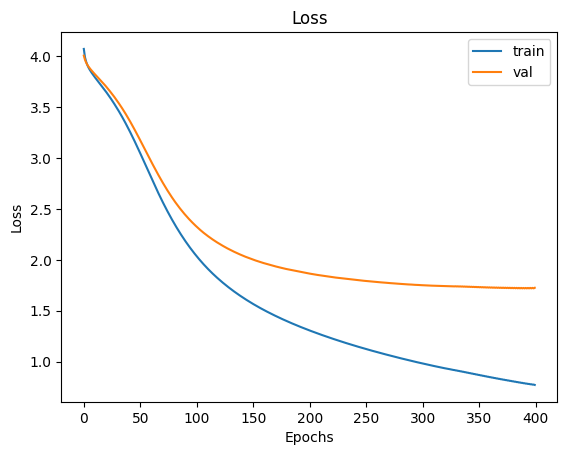

Accuracy train: 0.82
Accuracy val: 0.57


In [355]:
from src import models
importlib.reload(models)
from src.models import NN

# hiperparams
lr = 0.1
n_epochs = 400
batch_size = len(X_train)
l2_lambda = 0
early_stop_patience = 100
# Modelo y entrenamiento
M1d = NN(input_shape,
         output_shape,
         neurons_per_hidden_layer,
         lr,
         batch_size=batch_size,
         l2=l2_lambda)

M1d_history = M1d.fit(X_train,
                      y_train_ohe,
                      X_val,
                      y_val_ohe,
                      n_epochs)

# Visualización de losses
plt.plot(M1d_history['train_loss'], label='train')
plt.plot(M1d_history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


#Accuracy
y_train_pred = M1d.predict(X_train)  # (N,)
y_val_pred = M1d.predict(X_val)

acc_train_M1d = accuracy(y_train_labels, y_train_pred)
acc_val_M1d   = accuracy(y_val_labels, y_val_pred)
print(f"Accuracy train: {acc_train_M1d:.2f}")
print(f"Accuracy val: {acc_val_M1d:.2f}")


3.6  Regularización mediante dropout.

Epoch 1/1000, Train loss: 4.07322980121836
Epoch 2/1000, Train loss: 3.9922971817886097
Epoch 3/1000, Train loss: 3.949266890577892
Epoch 4/1000, Train loss: 3.918239044459188
Epoch 5/1000, Train loss: 3.893486069006225
Epoch 6/1000, Train loss: 3.8727023846651547
Epoch 7/1000, Train loss: 3.854475031644821
Epoch 8/1000, Train loss: 3.837633177221045
Epoch 9/1000, Train loss: 3.8217508025047158
Epoch 10/1000, Train loss: 3.806486321626596
Epoch 11/1000, Train loss: 3.791679023463357
Epoch 12/1000, Train loss: 3.777316824835529
Epoch 13/1000, Train loss: 3.76311479777396
Epoch 14/1000, Train loss: 3.748905999150171
Epoch 15/1000, Train loss: 3.7347246479255705
Epoch 16/1000, Train loss: 3.7204458698952827
Epoch 17/1000, Train loss: 3.706027418787077
Epoch 18/1000, Train loss: 3.691514231155624
Epoch 19/1000, Train loss: 3.676841174252422
Epoch 20/1000, Train loss: 3.661879054234081
Epoch 21/1000, Train loss: 3.6466577526191837
Epoch 22/1000, Train loss: 3.6312661510494575
Epoch 23/1000,

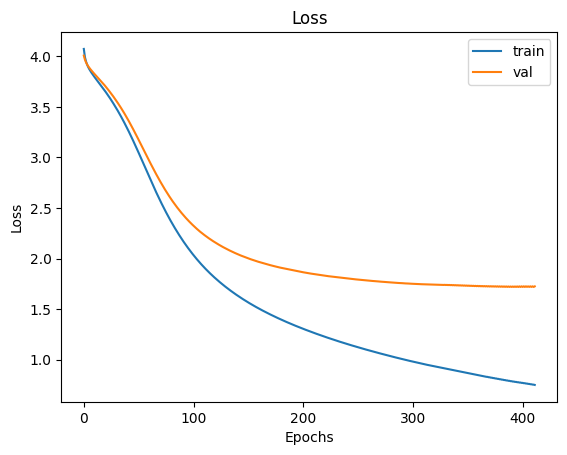

Accuracy train: 0.82
Accuracy val: 0.56


In [ ]:
from src import models
importlib.reload(models)
from src.models import NN

# hiperparams
lr = 0.1
n_epochs = 1000
batch_size = len(X_train)
l2_lambda = 0
early_stop_patience = 20
p_dropout = 0.5
# Modelo y entrenamiento
M1d = NN(input_shape,
         output_shape,
         neurons_per_hidden_layer,
         lr,
         batch_size=batch_size,
         l2=l2_lambda,
         early_stop_patience=early_stop_patience,
         use_dropout=True,
         p_dropout=p_dropout)

M1d_history = M1d.fit(X_train,
                      y_train_ohe,
                      X_val,
                      y_val_ohe,
                      n_epochs)

# Visualización de losses
plt.plot(M1d_history['train_loss'], label='train')
plt.plot(M1d_history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


#Accuracy
y_train_pred = M1d.predict(X_train)  # (N,)
y_val_pred = M1d.predict(X_val)

acc_train_M1d = accuracy(y_train_labels, y_train_pred)
acc_val_M1d   = accuracy(y_val_labels, y_val_pred)
print(f"Accuracy train: {acc_train_M1d:.2f}")
print(f"Accuracy val: {acc_val_M1d:.2f}")


In [364]:
final_loss = M1d_history['val_loss'][-1]

final_loss_train = M1d_history['train_loss'][-1]
print(f"Final train loss: {final_loss_train:.4f}")
final_loss_val = M1d_history['val_loss'][-1]
print(f"Final val loss: {final_loss_val:.4f}")

Final train loss: 0.7501
Final val loss: 1.7247


Pruebas de combinaciones (tipo grid-search). Aclaración: esta celda está codeada con ChatGPT.

In [370]:
# ---------------- 1. LIBRERÍAS Y DATOS ----------------
import time, importlib, pandas as pd
from src import models
importlib.reload(models)
from src.models import NN

# Se supone cargado:
# X_train, y_train_ohe, y_train_labels
# X_val,   y_val_ohe,   y_val_labels
# input_shape, output_shape

# ---------------- 2. DEFINICIÓN DE ESPACIOS -----------
architectures = {
    "A1": [128,  64],                   # 2 capas
    "A2": [256, 128,  64],              # 3 capas
    "A3": [256, 256, 128, 64],          # 4 capas
}

batch_sizes   = [32, 64]
optim_lrs     = {
    "sgd" : [0.05, 0.02],
    "adam": [0.001, 0.0005],
}
reg_types     = ["l2", "drop"]          # L2(1e-3)  ó  Dropout(0.5)

search_space = []
for arch_name, arch in architectures.items():
    for optimizer, lrs in optim_lrs.items():
        for lr in lrs:
            for reg in reg_types:
                for bs in batch_sizes:
                    search_space.append(dict(
                        architecture        = arch_name,
                        neurons_per_layer   = arch,
                        optimizer           = optimizer,
                        lr0                 = lr,
                        l2                  = 1e-3 if reg == "l2" else 0.0,
                        use_dropout         = (reg == "drop"),
                        batch_size          = bs,
                    ))

print(f"🌙 Ejecuciones programadas: {len(search_space)} (deberían ser 48)")

# ---------------- 3. CONSTANTES GENERALES -------------
P_DROPOUT   = 0.5
PATIENCE    = 40            # más alto por mini-batch
MAX_EPOCHS  = 2000          # early-stopping cortará antes
results     = []

# ---------------- 4. BUCLE PRINCIPAL ------------------
t0 = time.time()
for run_id, cfg in enumerate(search_space, 1):
    print(f"\n▶ Run {run_id}/{len(search_space)} — {cfg}")

    model = NN(
        input_shape, output_shape, cfg["neurons_per_layer"],
        lr0                 = cfg["lr0"],
        optimizer           = cfg["optimizer"],
        batch_size          = cfg["batch_size"],
        l2                  = cfg["l2"],
        early_stop_patience = PATIENCE,
        use_dropout         = cfg["use_dropout"],
        p_dropout           = P_DROPOUT,
    )

    history = model.fit(
        X_train, y_train_ohe,
        X_val,   y_val_ohe,
        epochs = MAX_EPOCHS,
    )

    # ---------------- 5. MÉTRICAS ----------------------
    y_val_pred = model.predict(X_val)
    val_acc    = accuracy(y_val_labels, y_val_pred)
    y_tr_pred  = model.predict(X_train)
    tr_acc     = accuracy(y_train_labels, y_tr_pred)

    elapsed = (time.time() - t0) / 60
    print(f"   ✔ val_acc = {val_acc:.4f} | tr_acc = {tr_acc:.4f}"
          f"   (tiempo total {elapsed:.1f} min)")

    results.append(dict(cfg, val_acc=val_acc, tr_acc=tr_acc))

# ---------------- 6. RESULTADOS FINALES ---------------
df = (pd.DataFrame(results)
        .sort_values("val_acc", ascending=False)
        .reset_index(drop=True))

display(df)                               # en Jupyter
df.to_csv("grid_architectures_results.csv", index=False)
print("\n🏁 Listo. Resultados guardados en grid_architectures_results.csv")

🌙 Ejecuciones programadas: 48 (deberían ser 48)

▶ Run 1/48 — {'architecture': 'A1', 'neurons_per_layer': [128, 64], 'optimizer': 'sgd', 'lr0': 0.05, 'l2': 0.001, 'use_dropout': False, 'batch_size': 32}
Epoch 1/2000, Train loss: 3.6512908022029564
Epoch 2/2000, Train loss: 2.8003041503605908
Epoch 3/2000, Train loss: 2.1826848817430062
Epoch 4/2000, Train loss: 1.8237676322181533
Epoch 5/2000, Train loss: 1.581658792416265
Epoch 6/2000, Train loss: 1.39824735119383
Epoch 7/2000, Train loss: 1.2567936038550565
Epoch 8/2000, Train loss: 1.1334984918238713
Epoch 9/2000, Train loss: 1.0275955621127668
Epoch 10/2000, Train loss: 0.9445899997527971
Epoch 11/2000, Train loss: 0.8477071814715235
Epoch 12/2000, Train loss: 0.7669214811603712
Epoch 13/2000, Train loss: 0.7010856306457165
Epoch 14/2000, Train loss: 0.6322190234043703
Epoch 15/2000, Train loss: 0.5723268045492951
Epoch 16/2000, Train loss: 0.5210083992890863
Epoch 17/2000, Train loss: 0.47206222917121793
Epoch 18/2000, Train loss:

,architecture,neurons_per_layer,optimizer,lr0,l2,use_dropout,batch_size,val_acc,tr_acc
0,A2,"[256, 128, 64]",adam,0.0010,0.001,False,64,0.68,1.00
1,A2,"[256, 128, 64]",adam,0.0010,0.001,False,32,0.65,1.00
2,A2,"[256, 128, 64]",adam,0.0005,0.001,False,64,0.65,0.97
3,A1,"[128, 64]",adam,0.0010,0.001,False,64,0.64,0.93
4,A3,"[256, 256, 128, 64]",adam,0.0005,0.001,False,32,0.63,0.94
5,A1,"[128, 64]",adam,0.0005,0.001,False,32,0.63,0.93
6,A3,"[256, 256, 128, 64]",adam,0.0010,0.001,False,64,0.62,0.92
7,A2,"[256, 128, 64]",adam,0.0005,0.001,False,32,0.62,0.94
8,A1,"[128, 64]",sgd,0.0500,0.000,True,32,0.61,0.90
9,A3,"[256, 256, 128, 64]",adam,0.0005,0.001,False,64,0.61,0.94



🏁 Listo. Resultados guardados en grid_architectures_results.csv


In [ ]:
BEST_PARAMS = {
    'neurons_per_layer': [256, 128, 64],
    'optimizer': 'adam',
    'lr0': 0.001,
    'batch_size': 64,
    'l2': 0.0,
    'use_dropout': False,
    'p_dropout': 0.5,
}

## 4. Desarrollo de una Red Neuronal con PyTorch


In [ ]:
import torch
